## Model Training and Evaluation ##

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

In [3]:
df = pd.read_csv("../Dataset/cleaned_gcs_kushal.csv")
df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,endoscopic_images,biopsy_results,ct_scan,...,label,existing_conditions_Chronic Gastritis,existing_conditions_Diabetes,existing_conditions_Unknown,mature_mirna_id_MIR123_1,mature_mirna_id_MIR234_2,mature_mirna_id_MIR345_3,target_symbol_CDH1,target_symbol_KRAS,target_symbol_TP53
0,43,1,1,0,0,0,0,0,0,0,...,0,True,False,False,True,False,False,False,False,True
1,86,0,1,0,0,1,1,0,0,0,...,0,False,True,False,False,True,False,False,False,True
2,68,1,0,1,1,0,1,0,0,0,...,0,False,False,True,False,False,True,False,True,False
3,57,0,0,0,0,1,1,0,0,0,...,0,True,False,False,True,False,False,False,True,False
4,33,1,0,1,1,0,1,1,0,0,...,0,False,True,False,True,False,False,True,False,False


### Features and Target ###

In [4]:
X = df.drop("label", axis=1)
y = df["label"]

### Training and Testing Data ###

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_test, y_test, y_train


(        age  gender  family_history  smoking_habits  alcohol_consumption  \
 51311    44       1               0               1                    0   
 140565   47       1               1               1                    0   
 95998    31       1               0               1                    1   
 69296    63       0               0               0                    1   
 21507    65       1               0               0                    0   
 ...     ...     ...             ...             ...                  ...   
 43002    38       1               0               0                    0   
 64109    23       1               0               0                    1   
 102177   22       0               0               1                    1   
 189015   72       1               0               1                    0   
 25712    33       0               1               1                    0   
 
         helicobacter_pylori_infection  dietary_habits  endoscopic_images 

### ML Pipeline ###

In [ ]:
from sklearn.pipeline import pipeline

from sklearn.ensemble import RandomForestClassifier

In [38]:
# Features only
X_only = df.drop(columns=["label"])

# Find duplicated feature rows
duplicates = df[X_only.duplicated(keep=False)]

print("Duplicate rows:", len(duplicates))

Duplicate rows: 0


In [8]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['age','gender','family_history',...,'target_symbol_CDH1', 'target_symbol_KRAS','target_symbol_TP53']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42


In [9]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [10]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9012973558428103
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.49221844589114594


/Users/kushalthapa/Desktop/gastric_cancer/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     38279
           1       0.00      0.00      0.00      4192

    accuracy                           0.90     42471
   macro avg       0.45      0.50      0.47     42471
weighted avg       0.81      0.90      0.85     42471



/Users/kushalthapa/Desktop/gastric_cancer/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushalthapa/Desktop/gastric_cancer/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushalthapa/Desktop/gastric_cancer/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

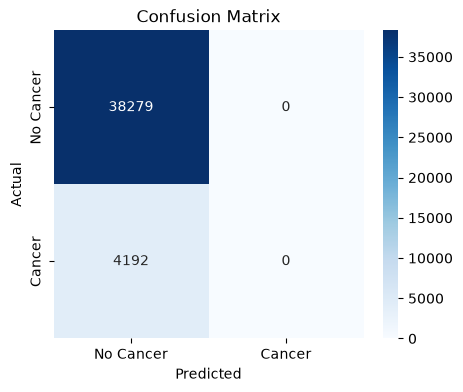

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Cancer","Cancer"],
    yticklabels=["No Cancer","Cancer"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38279     0]
 [ 4192     0]]


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     38279
           1       0.10      0.12      0.11      4192

    accuracy                           0.81     42471
   macro avg       0.50      0.50      0.50     42471
weighted avg       0.82      0.81      0.81     42471

